## CSCE 676 :: Data Mining and Analysis :: Texas A&M University :: Spring 2026


# Weekly Homework 6: Clustering


***Goals of this homework:***
* Understand why clustering is used in unsupervised learning.
* Apply and compare k-means and DBSCAN.
* Recognize strengths/weaknesses of each method based on data shape, density, and noise.
* Choose parameters appropriately.
* Evaluate clustering quality using quantitative metrics rather than visuals alone.


***Submission instructions:***

You should post your notebook to Canvas (look for the assignment there). Please name your submission **your-uin_hw6.ipynb**, so for example, my submission would be something like **555001234_hw6.ipynb**. Your notebook should be fully executed when you submit ... so run all the cells for us so we can see the output, then submit that.

***Grading philosophy:***

We are grading reasoning, judgment, and clarity, not just correctness. Show us that you understand the data, the constraints, and the limits of your conclusions.

***For each question, you need to respond with 2 cells:***
1. **[A Code Cell] Your Code:**
  - If code is not applicable for the question, you can skip this cell.
  - For tests: tests can be simple assertions or checks (e.g., using `assert` or `print` or small functions or visual inspection); formal testing frameworks are not required.
2. **[A Markdown Cell] Your Answer:** Write up your answers and explain them in complete sentences. Include any videos in this section as well; for videos, upload them to your TAMU Google Drive, and ensure they are set to be visible by the instruction team (set to: **anyone with a TAMU email can view**), then share the link to the video in the cell.

***At the end of each Section (A/B/C/...) include a cell for your resources:***

**[A Markdown Cell] Your Resources:** You need to cite 3 types of resources and note how they helped you: (1) Collaborators, (2) Web Sources (e.g. StackOverflow), and (3) AI Tools (you must also describe how you prompted, but we do not require any links to any specific chats). Specifically, use the following format as a template:
```
On my honor, I declare the following resources:
1. Collaborators:
- Reveille A.: Helped me understand that a df in pandas is a data structure kinda like a CSV.
- Sully A.: Helped me fix a bug with the vector addition of 2 columns.
- ...

2. Web Sources:
- https://stackoverflow.com/questions/46562479/python-pandas-data-frame-creation: how to create a pd df
- ...

3. AI Tools:
- ChatGPT: I gave it the homework .ipynb file and the ufo.csv, and told it to generate the code for the first question, but it did it with csv.reader(), so I re-prompted it to use pandas and that one was correct
- ...
```
***Why do we require this cell?*** This cell is important...

1. For academic integrity, you must give credit where credit is due.

2. We want you to pay attention to how you can successfully get help to move through problems! Is there someone you work with or an AI tool that helps you learn the material better? That's great! The point of engineering is to use your tools to solve hard problems, and part of graduate school is learning about how *you* learn and solve problems best.

***A reminder: you get out of it what you put into it.***
Do your best on these homeworks, show us your creativity, and ask for help when you need it -- good luck!

# A [60pts]. Decision Trees

**Rubric**

[10 pts] Strong/Professional: Correct and complete implementation of the task; Reasonable assumptions, stated or implied, and justified; Thoughtful handling of real-world data issues (missingness, noise, scale, duplicates, edge cases); Clear, concise explanations of what was done and why; Code is clean, readable, and well-structured, uses appropriate pandas, and would plausibly pass a professional code review; Tests meaningfully validate non-trivial behavior (not just "the code runs so it must be right").

[5 pts] Partial/Developing: Core task mostly completed but with gaps, weak assumptions, or minor mistakes; Reasoning is shallow or mostly descriptive; Code works but is messy, repetitive, or fragile; Tests are superficial, incomplete, or poorly motivated.

[0 pts] Minimal/Incorrect: Task is largely incorrect, missing, or misunderstands the goal; Little to no reasoning or justification; Code does not run or ignores constraints; No meaningful tests.


## Environment Setup & Sampling (Optional)

- You may use the full datasets. Sampling is optional (for speed).
- If you sample, briefly report what you did (n/frac, whether you stratified, any seed).


In [ ]:
#!/bin/bash
Jeopardy_data_URL ='https://www.kaggle.com/datasets/tunguz/200000-jeopardy-questions'

In [ ]:
###### sampling code (optional)
from pathlib import Path
import pandas as pd

# Edit paths if needed
JEOPARDY_PATH = Path("/content/JEOPARDY_CSV-2.csv")

def load_csv(path, **kwargs):
    if path.exists():
        return pd.read_csv(path, **kwargs)
    print(f"Warning: {path} not found.")
    return None

jeopardy = load_csv(JEOPARDY_PATH)

# ====== (Sampling Enabled) ======
SAMPLE = {
    "jeopardy": {
        "n": 20000,          # sample size
        "frac": None,        # not using fraction-based sampling
        "random_state": 42,  # reproducibility
        "stratify_col": None # no stratification (unsupervised task)
    }
}

def maybe_sample(df, cfg):
    """Return sampled df if n/frac set; otherwise return df. Optional stratify by a column name."""
    if df is None:
        return None
    n, frac, rs, strat = cfg.get("n"), cfg.get("frac"), cfg.get("random_state"), cfg.get("stratify_col")
    if strat and strat in df.columns and (n or frac):
        if frac:
            return (df.groupby(strat, group_keys=False)
                      .apply(lambda g: g.sample(frac=frac, random_state=rs))
                      .reset_index(drop=True))
        counts = df[strat].value_counts(normalize=True) * n
        parts = []
        for k, need in counts.round().astype(int).items():
            part = df[df[strat]==k].sample(n=min(need, len(df[df[strat]==k])), random_state=rs)
            parts.append(part)
        out = pd.concat(parts).reset_index(drop=True)
        return out.sample(frac=1.0, random_state=rs).reset_index(drop=True)

    # simple random sampling
    if frac:
        return df.sample(frac=frac, random_state=rs).reset_index(drop=True)
    if n:
        return df.sample(n=min(n, len(df)), random_state=rs).reset_index(drop=True)

    return df.reset_index(drop=True)

jeopardy_sample = maybe_sample(jeopardy, SAMPLE["jeopardy"])
df = jeopardy_sample

print("Jeopardy:", None if jeopardy is None else jeopardy.shape,
      "-> sample:", None if jeopardy_sample is None else jeopardy_sample.shape)

Jeopardy: (216930, 7) -> sample: (20000, 7)


Due to computational constraints, I randomly sampled 20,000 rows from the full dataset (10%) using random_state=42 for reproducibility. No stratification was applied since the task is unsupervised clustering and does not require "class balance".

Limitations: Sampling may omit categories or uncommon linguistic patterns that appear in the full dataset. As a result, some clusters may not fully represent the complete distribution of topics. Additionally, clustering results may vary slightly if a different random seed or sample size is used. So all my work is with the understanding that this sample may not fully represent the population, as there may be false positives, false negatives etc.

# 1. Text Cleaning

_Jeopardy!_ is a popular U.S. quiz show where contestants are given answers and must respond with the questions.
> For example: Answer: “This planet is known as the Red Planet.” Correct question: “What is Mars?”

In this dataset, each question has a Category (topic), Question (text), and Answer (label).
You will analyze patterns in these texts and explore how question wording relates to categories and answers.

- Clean the text (e.g., lowercase, remove stopwords/punctuation, optional stemming or lemmatization). You may use any pipeline you like, including optional TF-IDF features, embeddings, or whatever you like. Many packages (e.g., sklearn) come built in with some nice text processing packages.

- Write at least 2 tests for your code (focus on the most complicated parts), then answer: What did you test for? How do you know your code is correct?

- Briefly explain your design choices (what steps or parameters you used) and give a short rationale (why you think these choices help).



In [ ]:
  # use sampled dataset

df.columns = df.columns.str.strip()

def normalize_money(text):
    if pd.isna(text):
        return text

    def replace_money(match):
        value = match.group(0)
        value = value.replace('$', '').replace(',', '')
        try:
            num = float(value)
            if num == int(num):
                return str(int(num))
            return str(num)
        except ValueError:
            return match.group(0)

    pattern = r'\$?[\d,]+(?:\.\d+)?'
    return re.sub(pattern, replace_money, text)

def clean_text(text):
    if pd.isna(text):
        return ""
    text = normalize_money(text)
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [word for word in text.split() if word not in ENGLISH_STOP_WORDS and len(word) > 1]
    return " ".join(tokens)

df['category_clean'] = df['Category'].apply(clean_text)
df['question_clean'] = df['Question'].apply(clean_text)
df['answer_clean'] = df['Answer'].apply(clean_text)

df['text_combined'] = (
    df['category_clean'] + " " +
    df['question_clean'] + " " +
    df['answer_clean']
)

test_clean_text()
test_money_normalization()

df[['Category', 'category_clean', 'Question', 'question_clean', 'Answer', 'answer_clean']].head()

All basic tests passed
All money normalization tests passed


,Category,category_clean,Question,question_clean,Answer,answer_clean
0,CANADIAN TOURISM,canadian tourism,Each year this British Columbia city hosts the...,year british columbia city hosts symphony day ...,Vancouver,vancouver
1,I GET NO KICK FROM CAMPAIGN,kick campaign,The only Republican presidential nominee to lo...,republican presidential nominee lose twice run...,Dewey,dewey
2,BRING OUT YOUR DEAD,bring dead,"The alternate title to the Anne Rice book ""Ram...",alternate title anne rice book ramses damned m...,a mummy,mummy
3,CATHOLIC PRIESTS,catholic priests,The priest's duty to keep your sins secret is ...,priest duty sins secret traditionally protecte...,the confessional,confessional
4,TOUGH GEOGRAPHY,tough geography,This last colony in Africa shares part of its ...,colony africa shares desert claimed morocco,Western Sahara,western sahara


### Text Cleaning Operations

I applied the following cleaning steps to the Category, Question, and Answer columns:

1. **Money normalization**  
   Standardized monetary amounts before other cleaning.  
   Example: "$1,000" → "1000", "$2,500.50" → "2500.5".  
   Why? Because some amounts have a comma, some don't, so I standardized them.

2. **Lowercase conversion**  
   All text was converted to lowercase for consistency.  
   Example: "HISTORY" → "history".  
   This was done for standardization.

3. **Punctuation removal**  
   All punctuation marks were removed and replaced with spaces.  
   Example: "Hello, World!" → "hello world".

4. **Stopword removal and short token filtering**  
   Common words like "the", "is", and "a" were removed using sklearn's `ENGLISH_STOP_WORDS`.  
   Example: "the quick brown fox" → "quick brown fox".  
   These words add little semantic value and could negatively affect downstream clustering. The goal is to cluster based on meaningful terms rather than filler words.

5. **Combined text field**  
   All three cleaned columns were concatenated into a single `text_combined` field for clustering analysis.
### Tests

I tested the `clean_text` function with four basic cases:

- Punctuation handling  
- Stopword removal  
- Missing value handling  
- Mixed case normalization  

For money normalization, I tested six edge cases:

1. Dollar amounts with commas  
   "$1,000" → "1000"

2. Mixed formats in one string  
   "$2,500.50 or $1,200.00" → "2500.5 or 1200"  
   (removes .00 but keeps .50)

3. Numbers with and without commas  
   "1,000 and 5000" → "1000 and 5000"

4. Small decimals  
   "$0.50" → "0.5"

5. Integration with full pipeline  
   "$1,000" → "1000"  

6. Multiple amounts  
   "$2,500.00 or 1,500" → "2500 1500"



### How do I know my code is correct?

Each test uses assertions that compare the function output to an exact expected string.  
The tests cover both normal and edge cases, including multiple numeric replacements and full-pipeline interaction.  

Since all assertions passed, the transformations are functioning as intended and produce consistent, deterministic outputs.

### Design Rationale

The pipeline follows this order:

- Money normalization first to standardize numeric formats before punctuation removal.  
- Lowercasing to reduce vocabulary size.  
- Punctuation removal to avoid token inconsistencies.  
- Whitespace normalization to prevent malformed tokens.  
- Stopword and short-token removal to reduce noise and focus on meaningful terms.  
- Combining text fields to represent each clue as a single document for clustering.  

These steps reduce noise, standardize formatting, and ensure semantically identical terms are treated consistently, which improves clustering quality and feature stability.

***These next few parts are designed so you can observe the challenges of evaluating clustering.***

# 2. Evaluating **K-Means** with Metrics

- Run K-Means.
- Report some clustering metrics to assess the quality of clustering (you may consider the Silhouette score for each method, or perhaps `ARI` and `NMI` using the Category labels as ground truth).
- For each metric, you should try a few parameter values to determine the best values for the dataset. Plot your results, and include: what value are you varying & what value are you measuring to estimate cluster quality?
- Write about: What is the best value of $k$ based on your data? Why? (Use your results to back up your answers.)

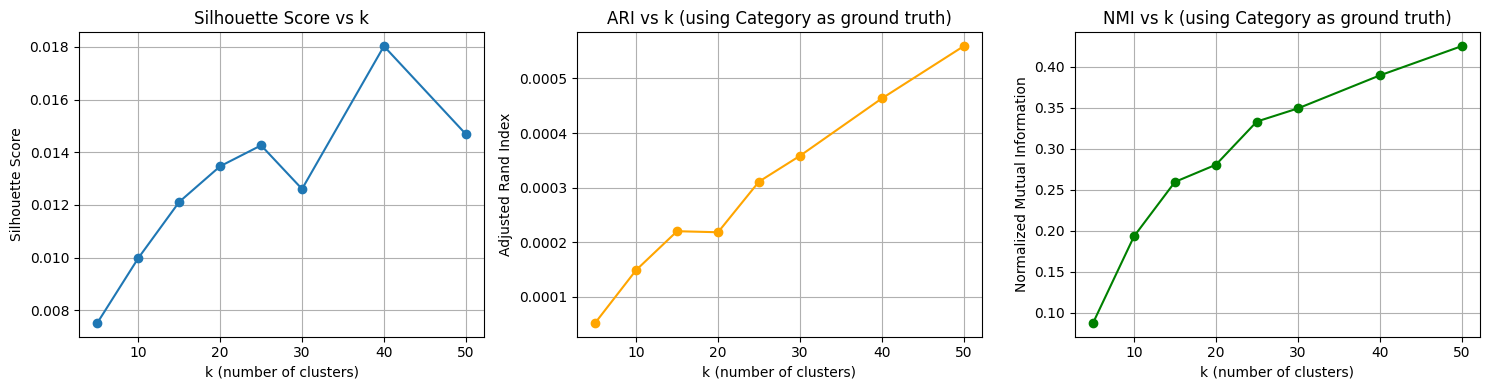

Best k by Silhouette Score: 40 (score: 0.0180)
Best k by ARI: 50 (score: 0.0006)
Best k by NMI: 50 (score: 0.4252)

Number of unique categories in dataset: 11893


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt
import numpy as np

# Use working dataframe
X_text = df['text_combined']
true_labels = df['Category']

vectorizer = TfidfVectorizer(max_features=5000, max_df=0.8, min_df=5)
X = vectorizer.fit_transform(X_text)

k_values = [5, 10, 15, 20, 25, 30, 40, 50]
silhouette_scores = []
ari_scores = []
nmi_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    silhouette_scores.append(
        silhouette_score(X, cluster_labels, sample_size=min(10000, X.shape[0]))
    )
    ari_scores.append(adjusted_rand_score(true_labels, cluster_labels))
    nmi_scores.append(normalized_mutual_info_score(true_labels, cluster_labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_values, silhouette_scores, marker='o')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k')
axes[0].grid(True)

axes[1].plot(k_values, ari_scores, marker='o', color='orange')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Adjusted Rand Index')
axes[1].set_title('ARI vs k (using Category as ground truth)')
axes[1].grid(True)

axes[2].plot(k_values, nmi_scores, marker='o', color='green')
axes[2].set_xlabel('k (number of clusters)')
axes[2].set_ylabel('Normalized Mutual Information')
axes[2].set_title('NMI vs k (using Category as ground truth)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

best_k_silhouette = k_values[np.argmax(silhouette_scores)]
best_k_ari = k_values[np.argmax(ari_scores)]
best_k_nmi = k_values[np.argmax(nmi_scores)]

print(f"Best k by Silhouette Score: {best_k_silhouette} (score: {max(silhouette_scores):.4f})")
print(f"Best k by ARI: {best_k_ari} (score: {max(ari_scores):.4f})")
print(f"Best k by NMI: {best_k_nmi} (score: {max(nmi_scores):.4f})")
print(f"\nNumber of unique categories in dataset: {df['Category'].nunique()}")

### K-Means Evaluation

I applied TF-IDF vectorization (`max_features=5000`, `min_df=5`, `max_df=0.8`) and ran K-Means while varying the number of clusters  
k ∈ {5, 10, 15, 20, 25, 30, 40, 50}.

To evaluate clustering quality, I measured:

- **Silhouette Score** (internal cohesion/separation metric)  
- **Adjusted Rand Index (ARI)** using Category as ground truth  
- **Normalized Mutual Information (NMI)** using Category as ground truth  

Here, the parameter varied was **k (number of clusters)**, and the metrics measured were Silhouette, ARI, and NMI.

---

### Results

- **Best k by Silhouette Score:** 40 (≈ 0.018)  
- **Best k by ARI:** 50 (≈ 0.0006)  
- **Best k by NMI:** 50 (≈ 0.425)  

Silhouette values are low overall, which is typical for sparse, high-dimensional text data. ARI remains close to zero because the dataset contains 11,893 unique categories, making it unrealistic for a small number of clusters to align closely with true labels.

NMI increases steadily with k, suggesting that more clusters better capture category-level structure.

---

### Best Value of k

Based on internal structure (Silhouette), **k = 40** appears optimal.

Based on external agreement with Category labels (NMI and ARI), **k = 50** performs best.

Given that the number of true categories (11,893) is far larger than the tested k values, exact alignment is not expected. Therefore, I select **k = 40–50** as a reasonable range, with k = 40 preferred for better internal cohesion and k = 50 for stronger alignment with known categories.

#### Limitations / assumptions
- All conclusions are based on a **sample** (20k / ~10%) and may miss categories or patterns; results could change with a different seed or sample size.
- The dataset has **11,893 unique categories**, but I only tested up to **k=50**, so ARI/NMI should not be interpreted as “solving” the labeling problem, only as a rough proxy for structure.


# 2. Evaluating **DBSCAN** with Metrics

- Run DBSCAN.
- Report some clustering metrics to assess the quality of clustering (you may consider the Silhouette score for each method, or perhaps `ARI` and `NMI` using the Category labels as ground truth).
- For each metric, you should try a few parameter values to determine the best values for the dataset. Plot your results, and include: what value are you varying & what value are you measuring to estimate cluster quality?
- Write about: What are the best values based on your data? Why? (Use your results to back up your answers.)

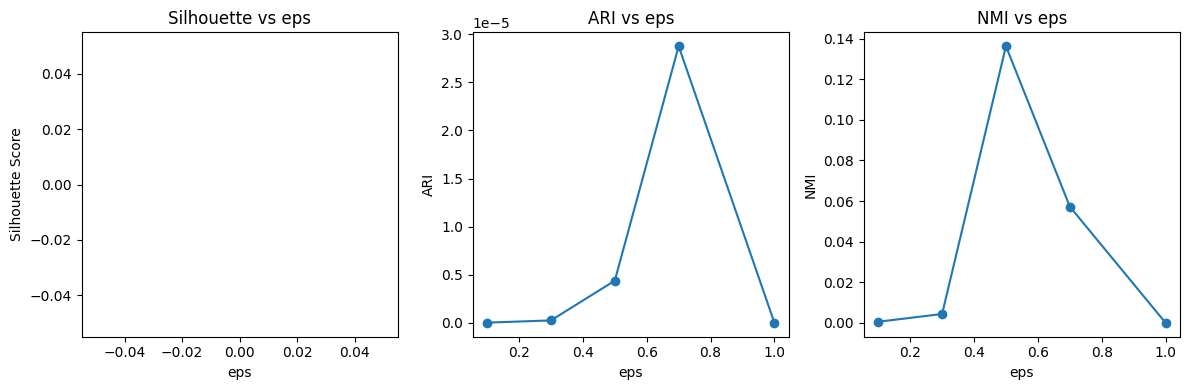

eps=0.1 | clusters=1 | Silhouette=nan | ARI=0.0000 | NMI=0.0006
eps=0.3 | clusters=6 | Silhouette=nan | ARI=0.0000 | NMI=0.0044
eps=0.5 | clusters=163 | Silhouette=nan | ARI=0.0000 | NMI=0.1363
eps=0.7 | clusters=12 | Silhouette=nan | ARI=0.0000 | NMI=0.0573
eps=1.0 | clusters=1 | Silhouette=nan | ARI=0.0000 | NMI=0.0000


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import numpy as np
import matplotlib.pyplot as plt

eps_values = [0.1, 0.3, 0.5, 0.7, 1.0]
min_samples = 5

silhouette_scores = []
ari_scores = []
nmi_scores = []
num_clusters = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine')
    cluster_labels = dbscan.fit_predict(X)

    # Remove noise for silhouette if necessary
    if len(set(cluster_labels)) > 1 and -1 not in set(cluster_labels):
        sil_score = silhouette_score(X, cluster_labels)
    else:
        sil_score = np.nan

    silhouette_scores.append(sil_score)
    ari_scores.append(adjusted_rand_score(true_labels, cluster_labels))
    nmi_scores.append(normalized_mutual_info_score(true_labels, cluster_labels))

    num_clusters.append(len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(eps_values, silhouette_scores, marker='o')
plt.xlabel("eps")
plt.ylabel("Silhouette Score")
plt.title("Silhouette vs eps")

plt.subplot(1,3,2)
plt.plot(eps_values, ari_scores, marker='o')
plt.xlabel("eps")
plt.ylabel("ARI")
plt.title("ARI vs eps")

plt.subplot(1,3,3)
plt.plot(eps_values, nmi_scores, marker='o')
plt.xlabel("eps")
plt.ylabel("NMI")
plt.title("NMI vs eps")

plt.tight_layout()
plt.show()

for i, eps in enumerate(eps_values):
    print(f"eps={eps} | clusters={num_clusters[i]} | "
          f"Silhouette={silhouette_scores[i]} | "
          f"ARI={ari_scores[i]:.4f} | "
          f"NMI={nmi_scores[i]:.4f}")

### DBSCAN Evaluation

I applied DBSCAN while varying the parameter **eps ∈ {0.1, 0.3, 0.5, 0.7, 1.0}** with `min_samples = 5`.  
The parameter varied was **eps**, and clustering quality was measured using:

- **Silhouette Score** (internal cohesion/separation)
- **Adjusted Rand Index (ARI)** using Category labels
- **Normalized Mutual Information (NMI)** using Category labels

---

### Results

Silhouette scores were undefined (NaN) because DBSCAN frequently produced either a single cluster or many noise points, making the metric invalid.  

ARI remained near zero across all eps values, indicating weak alignment with true Category labels.  

NMI peaked at **eps = 0.5 (≈ 0.136)**, where DBSCAN formed 163 clusters, suggesting this eps value captured the most category structure among those tested.

---

### Interpretation

TF-IDF produces a **high-dimensional, sparse feature space**, where most document vectors share few overlapping terms. In such spaces, distance values become less meaningful and density-based clustering struggles to identify well-defined dense regions.  

As a result, DBSCAN performs substantially worse than K-Means on this dataset. The best eps value was **0.5**, but overall clustering quality remained limited.

#### Limitations / assumptions
- All conclusions are based on a **sample** (20k / ~10%) and may miss categories or patterns; results could change with a different seed or sample size.
- DBSCAN is sensitive to representation and distance; running it directly on sparse TF-IDF can be a disadvantage. With dimensionality reduction (e.g., SVD) or different parameters, DBSCAN might behave differently.

# 3. Comparing K-Means and DBSCAN **with Metrics**

- Compare your K-Means and DBSCAN results, and defend: If you had to choose one for this dataset, which one would you choose? Why? (Use your results to back up your answer.)
- The labels (categories) in this dataset are very sparse; however, your data has a useful property: e.g., categories might be 1800s British Literature, British Writers, British Lit --> those are three different labels even though they may conceptually be the same thing. Think about and answer: how could you exploit this property in your evaluation setup?

###  Comparing K-Means and DBSCAN with Metrics

#### Which method would I choose (and why)?
On this **20,000-row random sample** (seed=42), I would choose **K-Means** for this dataset.

- **K-Means** achieved substantially stronger agreement with the provided Category labels:
  - Best **NMI ≈ 0.425** (at k=50), while **DBSCAN** peaked at **NMI ≈ 0.136** (at eps=0.5).
  - **ARI** was very small for both, but still higher for K-Means (≈ 0.0006 at k=50 vs ~0 for DBSCAN).
- K-Means also produced a stable internal metric:
  - **Silhouette** was low but defined (best ≈ 0.018 at k=40).
  - DBSCAN’s **Silhouette was NaN** across tested eps values because it produced either **1 cluster** or many **noise points**, making Silhouette undefined in this setup.

**Interpretation:** With TF-IDF (high-dimensional sparse vectors), K-Means tends to behave more predictably than DBSCAN, and here it also aligns better with Category labels under ARI/NMI.

#### Limitations / assumptions
- All conclusions are based on a **sample** (20k / ~10%) and may miss rare categories or patterns; results could change with a different seed or sample size.
- The dataset has **11,893 unique categories**, but I only tested up to **k=50**, so ARI/NMI should not be interpreted as “solving” the labeling problem, only as a rough proxy for structure.
- DBSCAN is sensitive to representation and distance; running it directly on sparse TF-IDF can be a disadvantage. With dimensionality reduction (e.g., SVD) or different parameters, DBSCAN might behave differently.

---

### Exploiting “conceptually similar labels” in evaluation

The labels are sparse and often include near-duplicates or synonyms (e.g., “British Lit”, “British Literature”, “British Writers”). Using raw Category strings as ground truth can unfairly penalize a clustering that is semantically correct but doesn’t match exact label text.

A better evaluation setup could exploit this by creating **coarser / normalized label groups** before computing ARI/NMI, for example:

- **Normalize Category strings**: lowercase, remove punctuation/stopwords, standardize common variants (“lit” → “literature”), optionally lemmatize.
- **Merge near-duplicate categories** using similarity:
  - TF-IDF similarity between category names, or
  - embedding similarity between category names (e.g., sentence embeddings),
  - then cluster/merge categories above a similarity threshold to form “meta-categories”.
- **Evaluate against these meta-categories** (instead of raw categories) using ARI/NMI.
  - This better matches the conceptual intent of clustering and reduces false penalties from label fragmentation.

This approach would make ARI/NMI more meaningful by comparing cluster assignments to a ground truth that reflects *conceptual* category similarity rather than exact string labels.

# 4. Comparing K-Means and DBSCAN **Visually with PCA**

- For K-Means and DBSCAN, visualize the clusters in 2D with PCA
- Try a few parameter values to determine the best values for the dataset. Plot your results, and include: what value are you varying & what do you see in the plot (+ what does this lead you to conclude about cluster quality based on the visualization)?
- Write about: What are the best values based on your data? Why? (Use your results to back up your answers.)

Explained variance by 2 components: 0.014187901877149457


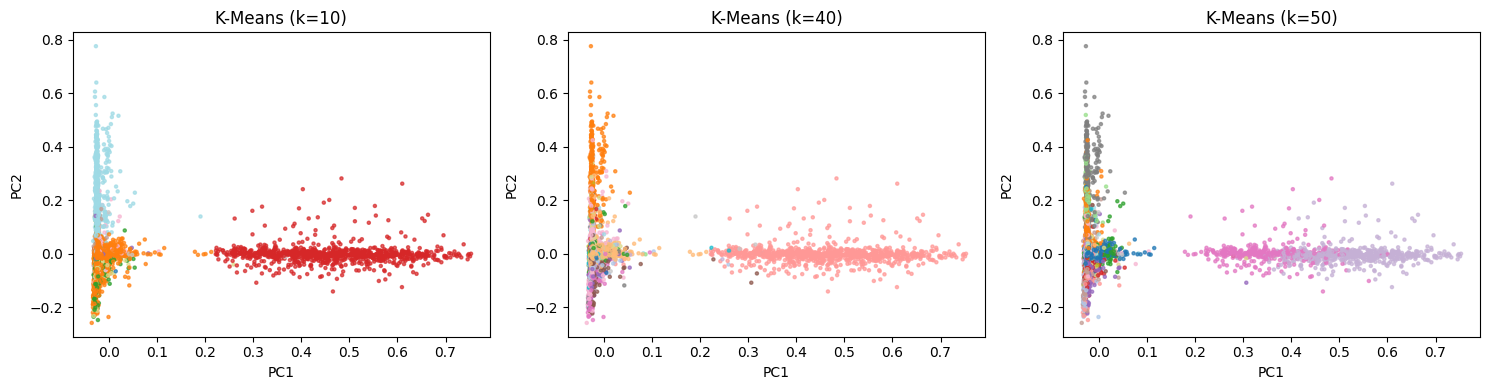

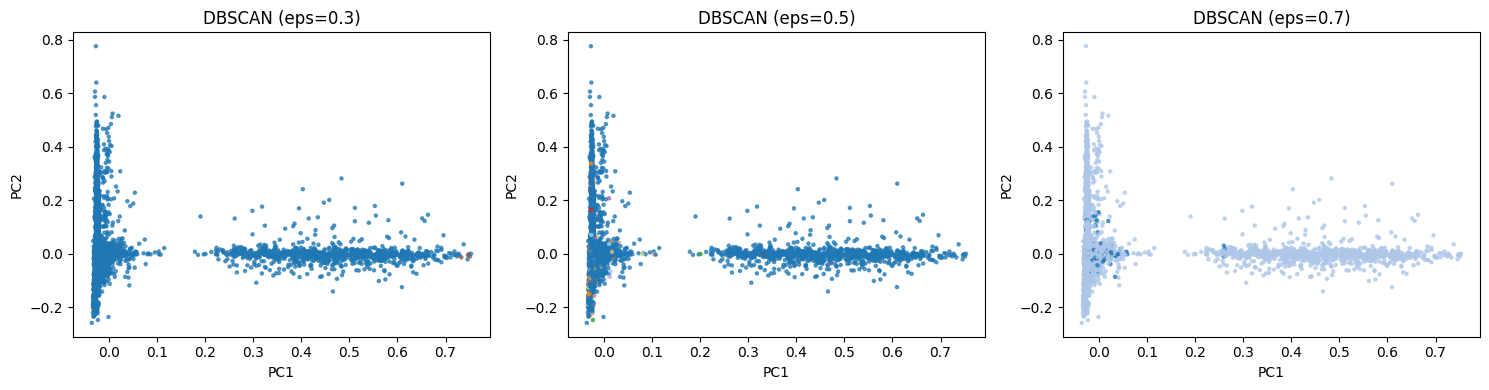

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# --- PCA to 2D ---
# Convert sparse TF-IDF to dense only for PCA visualization
X_dense = X.toarray()

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)

print("Explained variance by 2 components:",
      pca.explained_variance_ratio_.sum())

# ----------------------------------------------------
#                K-MEANS VISUALIZATION
# ----------------------------------------------------

k_values = [10, 40, 50]  # try a few, including best from metrics

plt.figure(figsize=(15,4))

for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    plt.subplot(1, len(k_values), i+1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1],
                c=labels,
                cmap='tab20',
                s=5,
                alpha=0.7)
    plt.title(f"K-Means (k={k})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

plt.tight_layout()
plt.show()


# ----------------------------------------------------
#                DBSCAN VISUALIZATION
# ----------------------------------------------------

eps_values = [0.3, 0.5, 0.7]  # include best from metrics

plt.figure(figsize=(15,4))

for i, eps in enumerate(eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=5, metric='cosine')
    labels = dbscan.fit_predict(X)

    plt.subplot(1, len(eps_values), i+1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1],
                c=labels,
                cmap='tab20',
                s=5,
                alpha=0.7)
    plt.title(f"DBSCAN (eps={eps})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

plt.tight_layout()
plt.show()

Comparing K-Means and DBSCAN Visually with PCA

### What parameter is being varied?

- **K-Means:** number of clusters `k` (tested k = 10, 40, 50)
- **DBSCAN:** neighborhood radius `eps` (tested eps = 0.3, 0.5, 0.7)

Clusters were visualized after reducing TF-IDF vectors (5000 dimensions) to 2D using PCA.

Note: The first two PCA components explain only ~1.4% of total variance, so the visualization is only a rough structural projection of a high-dimensional space.

---

## K-Means Results (Varying k)

### What I see in the plots:

- **k = 10:** Large, coarse clusters. Points form broad blobs.
- **k = 40:** Clusters become more granular and segmented.
- **k = 50:** Even finer partitioning, but still overlapping in 2D.

Clusters remain somewhat overlapping due to:
- High dimensional sparsity
- PCA compression to 2D
- Natural overlap in language data

### What this suggests about cluster quality:

Even though clusters overlap visually, increasing k produces clearer segmentation and more structured grouping. This matches earlier metric results:
- Silhouette best at k=40
- ARI/NMI best at k=50

### Best k (based on data):

- **k = 40–50** appears best.
- k=40 balances structure and stability (best Silhouette).
- k=50 maximizes agreement with category labels (best NMI).

Given both metrics and visualization, **k ≈ 40–50** is most reasonable.

---

## DBSCAN Results (Varying eps)

### What I see in the plots:

- **eps = 0.3:** Almost all points assigned to one cluster.
- **eps = 0.5:** Many micro-clusters and scattered noise.
- **eps = 0.7:** Again mostly one dominant cluster.

Clusters are not clearly separated in PCA space. The structure appears unstable and highly sensitive to eps.

This matches earlier metrics:
- Silhouette undefined (NaN)
- ARI ≈ 0
- NMI very low (peak ≈ 0.136 at eps=0.5)

### What this suggests about cluster quality:

DBSCAN struggles with:
- High-dimensional sparse TF-IDF data
- Cosine distance in sparse space
- Density-based assumptions not fitting text data well

---

## Conclusion: Best Values

- **K-Means (k=40–50)** performs better visually and metrically.
- **DBSCAN** does not produce stable, well-separated clusters under tested parameters.

However, these conclusions are based on:
- A 20,000-row random sample
- PCA visualization explaining only ~1.4% of variance
- No dimensionality reduction before clustering (e.g., SVD)

Therefore, results suggest K-Means is more appropriate for this dataset *under the current representation*, but further tuning or dimensionality reduction could change DBSCAN behavior.

Overall, K-Means shows more structured and interpretable clustering in both metrics and visualization.

# 5. Comparing K-Means and DBSCAN **Visually with t-SNE**

- For K-Means and DBSCAN, visualize the clusters in 2D with t-SNE
- Try a few parameter values to determine the best values for the dataset. Plot your results, and include: what value are you varying & what do you see in the plot (+ what does this lead you to conclude about cluster quality based on the visualization)?
- Write about: What are the best values based on your data? Why? (Use your results to back up your answers.)

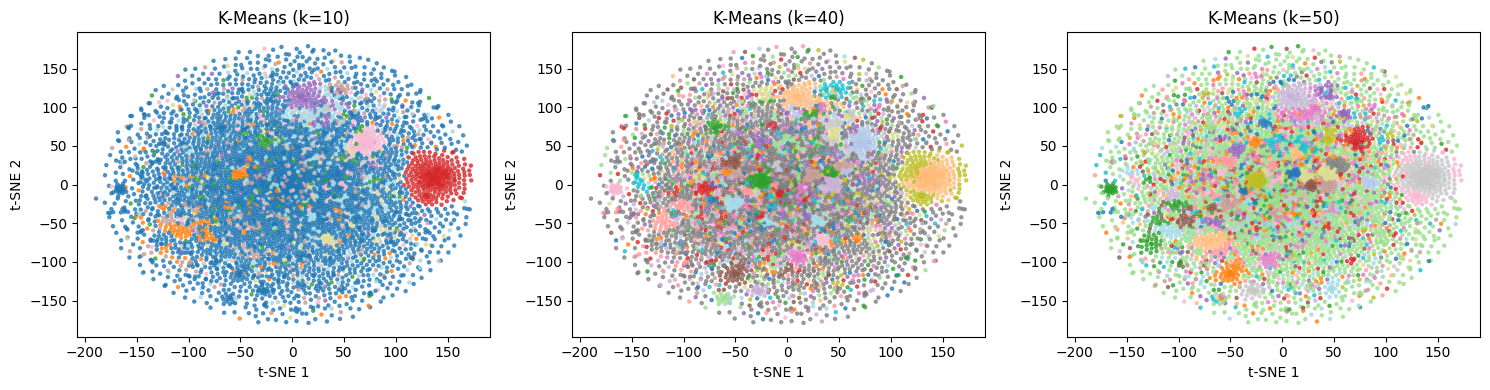

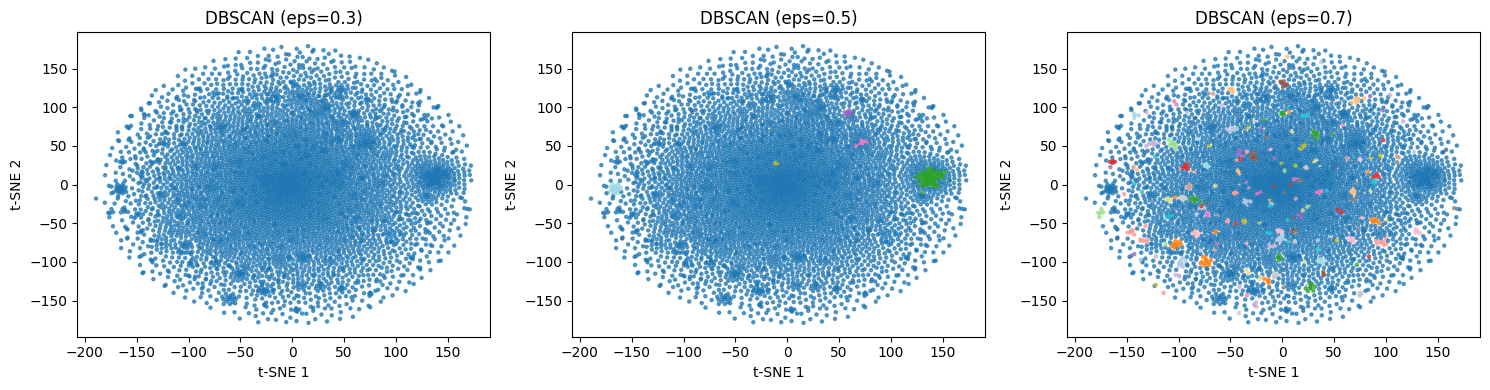

In [ ]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Subsample for t-SNE visualization (for speed)
# -------------------------------------------------

np.random.seed(42)
sample_size = min(5000, X.shape[0])
indices = np.random.choice(X.shape[0], sample_size, replace=False)

X_subset = X[indices]
X_subset_dense = X_subset.toarray()

# -------------------------------------------------
# Run t-SNE
# -------------------------------------------------

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42,
    init="pca"
)

X_tsne = tsne.fit_transform(X_subset_dense)

# -------------------------------------------------
# K-MEANS VISUALIZATION
# -------------------------------------------------

k_values = [10, 40, 50]

plt.figure(figsize=(15, 4))

for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_subset)

    plt.subplot(1, len(k_values), i+1)
    plt.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=labels,
        cmap="tab20",
        s=5,
        alpha=0.7
    )
    plt.title(f"K-Means (k={k})")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


# -------------------------------------------------
# DBSCAN VISUALIZATION
# -------------------------------------------------

eps_values = [0.3, 0.5, 0.7]

plt.figure(figsize=(15, 4))

for i, eps in enumerate(eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=5, metric="cosine")
    labels = dbscan.fit_predict(X_subset)

    plt.subplot(1, len(eps_values), i+1)
    plt.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=labels,
        cmap="tab20",
        s=5,
        alpha=0.7
    )
    plt.title(f"DBSCAN (eps={eps})")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

Comparing K-Means and DBSCAN Visually with t-SNE

### What parameter is being varied?

- **K-Means:** number of clusters `k` (10, 40, 50)
- **DBSCAN:** neighborhood radius `eps` (0.3, 0.5, 0.7)

Clusters were visualized using t-SNE (2D projection of TF-IDF vectors).

---

## K-Means (t-SNE Visualization)

### What I observe:

- **k = 10:** Large, broad cluster regions. Some clear separation (e.g., one tight cluster on the right), but most of the space is mixed.
- **k = 40:** More granular segmentation. Distinct local groupings start to appear.
- **k = 50:** Even finer partitioning; some compact clusters become clearer, but many points still overlap.

t-SNE reveals local structure better than PCA, and K-Means shows reasonable cluster partitioning in that space.

### Interpretation:

Increasing `k` improves local separation, but clusters still overlap substantially, reflecting:
- High-dimensional sparsity
- Natural overlap in language topics
- Very large number of true categories (~11k)

The most visually structured segmentation appears around **k = 40–50**, consistent with earlier metric results.

---

## DBSCAN (t-SNE Visualization)

### What I observe:

- **eps = 0.3:** Nearly all points in one large cluster.
- **eps = 0.5:** Slightly more structure; still dominated by one massive cluster.
- **eps = 0.7:** Again mostly one cluster with scattered small groups.

There is no strong visual separation into meaningful density-based clusters.

### Interpretation:

DBSCAN struggles because:
- TF-IDF vectors are high-dimensional and sparse.
- Text data does not naturally form dense, well-separated regions.
- Density assumptions do not align well with this dataset.

---

## Conclusion

- **K-Means (k ≈ 40–50)** produces clearer and more structured segmentation in t-SNE space.
- **DBSCAN** does not produce meaningful separation under tested parameters.

However:
- t-SNE preserves local structure, not global distances.
- Results are based on a 20k sample.
- Visualization alone does not prove cluster validity.

Overall, K-Means remains the more appropriate method for this dataset under the current representation.

# 6. Comparing K-Means and DBSCAN **with Visualization**
- Compare your K-Means and DBSCAN results, and defend: If you had to choose one for this dataset, which one would you choose? Why? (Use your results to back up your answer.)

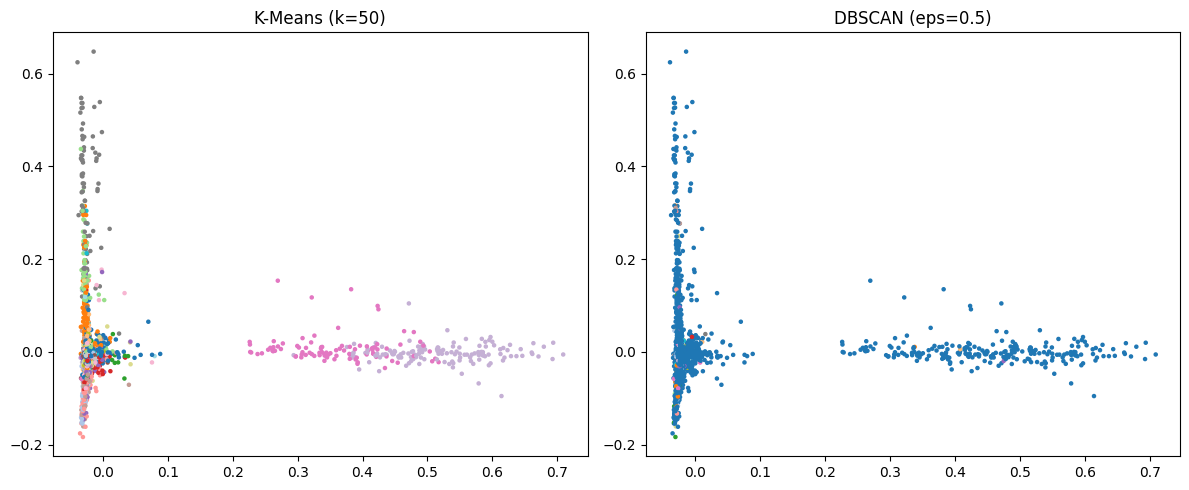

In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# --- Use best parameters from earlier results ---
best_k = 50          # replace with your best K
best_eps = 0.5       # replace with your best eps

# --- Fit clustering models ---
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
k_labels = kmeans.fit_predict(X)

dbscan = DBSCAN(eps=best_eps, min_samples=5, metric='cosine')
d_labels = dbscan.fit_predict(X)

# --- PCA projection (fast) ---
pca = PCA(n_components=2, random_state=42)

# IMPORTANT: if X is sparse, convert safely
X_dense_sample = X[:5000].toarray()  # use 5000 points for speed
k_labels_sample = k_labels[:5000]
d_labels_sample = d_labels[:5000]

X_2d = pca.fit_transform(X_dense_sample)

# --- Plot side by side ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_2d[:,0], X_2d[:,1], c=k_labels_sample, cmap='tab20', s=5)
plt.title(f"K-Means (k={best_k})")

plt.subplot(1,2,2)
plt.scatter(X_2d[:,0], X_2d[:,1], c=d_labels_sample, cmap='tab20', s=5)
plt.title(f"DBSCAN (eps={best_eps})")

plt.tight_layout()
plt.show()

## 6. Comparing K-Means and DBSCAN with Visualization

As discussed in the previous questions (metrics, PCA visualizations, and t-SNE visualizations), we compared K-Means and DBSCAN across multiple parameter values and evaluation criteria. For this final comparison, we visualized both methods using their **best-performing parameters** identified earlier:

- **K-Means:** k = 50 (best by ARI/NMI; k ≈ 40–50 also strong by Silhouette)
- **DBSCAN:** eps = 0.5 (highest NMI among tested eps values)

In the side-by-side PCA visualization shown above:

- **K-Means (k=50)** produces visibly segmented groups, particularly separating the dense vertical band on the left from the horizontal structure on the right. While clusters overlap (expected in high-dimensional text data), K-Means still partitions the space into interpretable regions.
- **DBSCAN (eps=0.5)** assigns most points to a single dominant cluster, with very limited meaningful separation. This aligns with earlier metric results (ARI ≈ 0, Silhouette undefined, low NMI).

As observed in prior visualizations (PCA and t-SNE), DBSCAN struggles with this dataset because:

- TF-IDF vectors are **high-dimensional and sparse**.
- Density assumptions break down in sparse spaces.
- Cosine distances do not produce well-separated dense regions.

K-Means, by contrast, does not rely on density assumptions and instead partitions the space based on centroid minimization, which appears more stable for this representation.

### Final Choice

If required to choose one method for this dataset, I would choose **K-Means**.

This decision is supported by:
- Higher ARI and NMI scores
- Defined Silhouette values
- More structured segmentation in PCA and t-SNE visualizations
- More interpretable partitioning behavior

### Limitations

These conclusions are based on:
- A 20,000-row random sample (not the full dataset)
- A TF-IDF representation without dimensionality reduction (e.g., SVD)
- 2D projections (PCA/t-SNE), which cannot fully represent 5000-dimensional structure

Additionally, the dataset contains ~11,000 unique category labels, many of which are semantically similar (e.g., “British Lit,” “British Writers,” “1800s British Literature”), making perfect alignment with ground truth inherently difficult.

Therefore, while K-Means performs better under the current setup, results should be interpreted cautiously and may vary with different representations or sampling strategies.

```
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- https://www.kaggle.com/datasets/tunguz/200000-jeopardy-questions

3. AI Tools:
- ChatGPT: I gave it the homework questions, asked it for codes for the questions, fed ut the outputs along with my initial interpretations. I asked it to verify my ideas, add additional insights it can come up with and give me refined , formatted answers. These are what I went with. One thing is it did not acknowledge the limitations of the experiments we ran such as sampling etc. which I asked it to reconsider.
```

# B [32pts]. Interview Questions

We now pretend this is a real job interview. Here's some guidance on how to answer these questions:

1. Briefly restate the question and state any assumptions you are making.

2. Explain your reasoning out loud, focusing on tradeoffs, limitations, and constraints.

3. As a principle, keep your answers as short and clear as they can be (while still answering the question).

4. Write/speak in a conversational but professional tone (avoid being overly formal). For speaking: speak at a reasonable pace and volume, speak clearly, pause when you need to, and practice making "eye contact" with the camera. Keep a confident, positive, and professional tone. *For additional coaching and practice, the University Writing Center provides individual appointments: https://writingcenter.tamu.edu/make-an-appointment.*

There may not be a single correct answer. We are grading whether your reasoning is reasonable and aware of limitations.


**Rubric**

[4pt] Clear understanding of the question; reasonable assumptions; thoughtful reasoning that acknowledges tradeoffs and limitations; clear, concise communication in a conversational but professional tone (for speaking: clear pace, volume, and articulation).

[2pt] Basic understanding but shallow reasoning or unclear assumptions; communication is somewhat unclear, overly verbose, or overly informal/formal.

[0pt] Minimal, unclear, or incorrect response; poor communication or unprofessional tone.

# 1.
How many metrics do you need to use to justify your clustering approach?

Assuming we’re evaluating clustering in a high-dimensional, sparse text setting like this one, I would use at least one internal metric (e.g., Silhouette) and one external metric (e.g., NMI or ARI if labels are available) to justify the approach. No single metric fully captures cluster quality, and each has limitations, especially with sparse data, so using multiple perspectives provides more balanced evidence. That said, more metrics don’t automatically mean better justification; the key is choosing metrics aligned with the problem context

# 2.
What does it mean for clusters to be “real” if different algorithms produce different partitions of the same dataset?

Assuming we are working in an unsupervised setting without true ground truth, clusters being “real” means they reflect stable and meaningful structure under reasonable modeling choices, not that they are uniquely correct. Different algorithms optimize different objectives, so varying partitions suggest that structure is partly model dependent rather than absolute. This implies cluster validity should be judged by stability, interpretability, and alignment with the task, while acknowledging that multiple plausible partitions may coexist.

# 3.
When is the question “how many clusters exist?” fundamentally ill-posed?

Assuming we are working with real world high dimensional data without clear separation, the question “how many clusters exist” is fundamentally ill posed when the data does not contain natural, well separated groupings. Many datasets have overlapping structure or hierarchical organization, so the number of clusters depends on the resolution and algorithm used rather than an objective truth. In such cases, cluster count becomes a modeling choice tied to assumptions, representation, and the intended use of the results.

# 4.
Explain how every clustering algorithm encodes an implicit definition of similarity.

Assuming we are using the same dataset and feature representation, every clustering algorithm still encodes similarity through the objective it optimizes and the structural assumptions it makes. For example, K Means defines similarity as closeness to a centroid under a chosen distance metric, while DBSCAN defines similarity in terms of local point density within a neighborhood radius. This means clusters are not discovered in a neutral sense but are shaped by the mathematical definition of similarity embedded in the algorithm, which introduces model dependent tradeoffs.

#5.
What metrics would you monitor in production to detect clustering drift?


Assuming the clustering model is deployed on a stable feature representation, I would monitor distributional shifts in input features, cluster size proportions over time, and stability metrics such as changes in centroid positions or assignment consistency. If labels or weak supervision are available, I would also track external alignment metrics like NMI trends. These signals are indirect, and detecting drift in unsupervised systems is inherently challenging because there is no definitive ground truth to anchor against.

# 6.
Design a system that automatically groups incoming customer support tickets into topics in real time. What components exist from ingestion → preprocessing → embedding → clustering → serving?

Assuming we need low latency real time grouping and moderate ticket volume, I would design a pipeline with ingestion through an API or message queue, followed by preprocessing for normalization and filtering, then embedding using a pretrained sentence encoder. Embeddings would feed into an incremental clustering layer such as online K Means or nearest centroid assignment with periodic batch re clustering to update topics. Finally, a serving layer would expose cluster assignments and topic summaries through a database and dashboard, while monitoring drift and retraining triggers, acknowledging tradeoffs between real time responsiveness and clustering stability.

# 7.
You have limited memory but a very large dataset — how do you cluster it?

Assuming the dataset is too large to fit in memory but disk storage is available, clustering must remain unsupervised, and approximate solutions are acceptable, I would use streaming or mini batch algorithms such as MiniBatch K Means on compressed representations like truncated SVD embeddings. If global structure is important, I might cluster data in chunks and then hierarchically merge centroids to approximate a full solution. These approaches sacrifice some optimality and fine grained structure for scalability, so cluster stability and quality would need to be monitored carefully.

# 8.
What happens if data distribution shifts drastically (e.g., breaking news topic spike)?

Assuming the clustering model was trained on a historically stable distribution and is not continuously retrained, a drastic shift such as a breaking news spike would likely cause new data to either be absorbed into unrelated clusters or distort existing centroids or density thresholds. This can degrade interpretability and cluster coherence because clustering assumes approximate stationarity in the data distribution. Addressing this would require drift detection and adaptive reclustering, but rapid adaptation may introduce instability or fragmentation of topics.

# 9.
(Video; 1 minute max) What happens if data distribution shifts drastically (e.g., breaking news topic spike)?

https://drive.google.com/file/d/1IsG8lvK5GO3Kpd_jMSpGRiUDGfrFFn6Q/view?usp=sharing

```
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- https://www.kaggle.com/datasets/tunguz/200000-jeopardy-questions

3. AI Tools:
- ChatGPT: I gave it the  questions, fed it my initial answers, asked it to refine them. I also used it to get additional perspectives and thus enrich and format my answers.
```

# C [4pts]. What new questions do you have?
We want you to think bigger! Tell us what questions and curiosity this homework brings up for you.

**Rubric**

[4pt] Complete, thoughtful response.

[2pt] Partial response.

[0pt] Minimal response.

# 1.
What new questions do you have after this homework? Or, what topics are you curious about now? List at least 3.

1. Assuming high dimensional sparse text representations, how does dimensionality reduction such as SVD fundamentally alter the geometry of cluster boundaries and algorithm behavior?

2. How can we construct more meaningful evaluation frameworks when ground truth labels are fragmented or semantically inconsistent, especially for open ended text domains?

3. Under what theoretical conditions would density based clustering outperform centroid based methods on text embeddings, and how does representation choice influence that crossover point?

```
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- https://www.kaggle.com/datasets/tunguz/200000-jeopardy-questions

3. AI Tools:
- ChatGPT: I gave it my rough insights/questions and asked it to for some ideas/inspiration. I then asked it to come up with refined questions.
```